In [ ]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np

LOG.propagate = False

ble = get_ble_controller()
ble.connect()

In [ ]:
ble.send_command(CMD.ECHO, "HiHello")
s = ble.receive_string(ble.uuid['RX_STRING'])
print(s)

In [16]:
ble.send_command(CMD.SEND_THREE_FLOATS, "0.2|-0.6|0.5")

In [ ]:
ble.send_command(CMD.GET_TIME_MILLIS, "")
s = ble.receive_string(ble.uuid['RX_STRING'])
print(s)

In [39]:
def handler(uuid, byte_array):
    s = ble.bytearray_to_string(byte_array);
    label,value = s.split(":")
    t = value.strip();
    print(t)

ble.start_notify(ble.uuid['RX_STRING'], handler)

In [55]:
ble.stop_notify(ble.uuid['RX_STRING'])

In [ ]:
def handler(uuid, byte_array):
    s = ble.bytearray_to_string(byte_array);
    print(s);
    
ble.start_notify(ble.uuid['RX_STRING'], handler)

ble.send_command(CMD.TIME_LOOP, "")

In [59]:
ble.stop_notify(ble.uuid['RX_STRING'])

In [61]:
timeArray = []

def handler(uuid, byte_array):
    s = ble.bytearray_to_string(byte_array);
    timeArray.append(s)

ble.start_notify(ble.uuid['RX_STRING'], handler)

ble.send_command(CMD.TIME_LOOP, "")

In [ ]:
print(len(timeArray))
print(timeArray)

In [ ]:
ble.stop_notify(ble.uuid['RX_STRING'])

In [86]:
timeArray = []
tempArray = []

def handler(uuid, byte_array):
    s = ble.bytearray_to_string(byte_array);
    time, temp = s.split()
    timeArray.append(time)
    tempArray.append(temp)

ble.start_notify(ble.uuid['RX_STRING'], handler)

ble.send_command(CMD.GET_TEMP_READINGS, "")

In [97]:
print(len(timeArray))
#print(timeArray)
print(len(tempArray))
#print(tempArray)

2000
2000


In [16]:
tof_time = []
tof_front = []
tof_right = []

imu_time = []
pitch = []
roll = []

mode = None   

def handler(uuid, byte_array):
    global mode

    s = ble.bytearray_to_string(byte_array).strip()

    if not s:
        return

    if s.startswith("TOF"):
        mode = "TOF"
        return

    if s.startswith("IMU"):
        mode = "IMU"
        return

    if s.startswith("DONE"):
        print("Log finished")
        return

    parts = s.split(",")

    try:
        if mode == "TOF":
            t = int(parts[0])
            f = int(parts[1])
            r = int(parts[2])
            tof_time.append(t)
            tof_front.append(f)
            tof_right.append(r)

        elif mode == "IMU":
            t = int(parts[0])
            p = float(parts[1])
            rr = float(parts[2])
            imu_time.append(t)
            pitch.append(p)
            roll.append(rr)

    except:
        pass  

ble.start_notify(ble.uuid['RX_STRING'], handler)

ble.send_command(CMD.READ_IMU_TOF, "")

In [ ]:
print("TOF samples:", len(tof_time))
print("TOF samples:", len(tof_front))
print("IMU samples:", len(tof_right))
print(tof_time)
print(tof_front)
print(tof_right)

In [ ]:
print("IMU samples:", len(imu_time))
print("IMU samples:", len(pitch))
print("IMU samples:", len(roll))
print(imu_time)
print(pitch)
print(roll)

In [15]:
ble.stop_notify(ble.uuid['RX_STRING'])

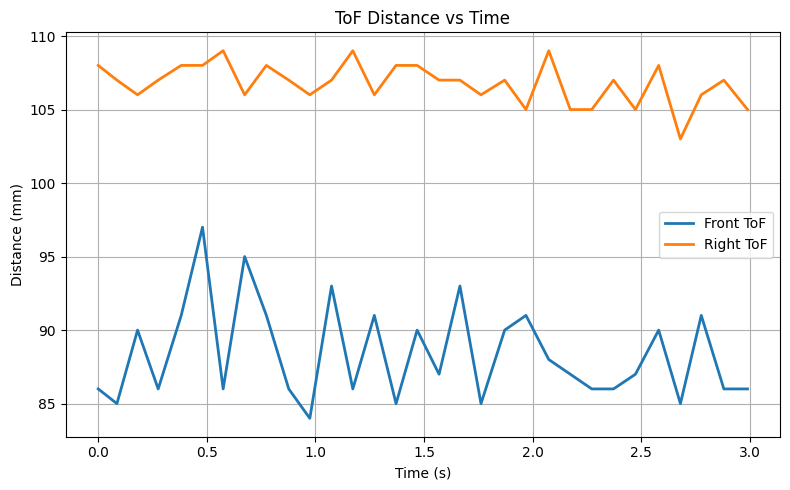

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(t, front, linewidth=2)
plt.plot(t, right, linewidth=2)

plt.xlabel("Time (s)")
plt.ylabel("Distance (mm)")
plt.title("ToF Distance vs Time")
plt.legend(["Front ToF", "Right ToF"])
plt.grid(True)

plt.tight_layout()
plt.show()

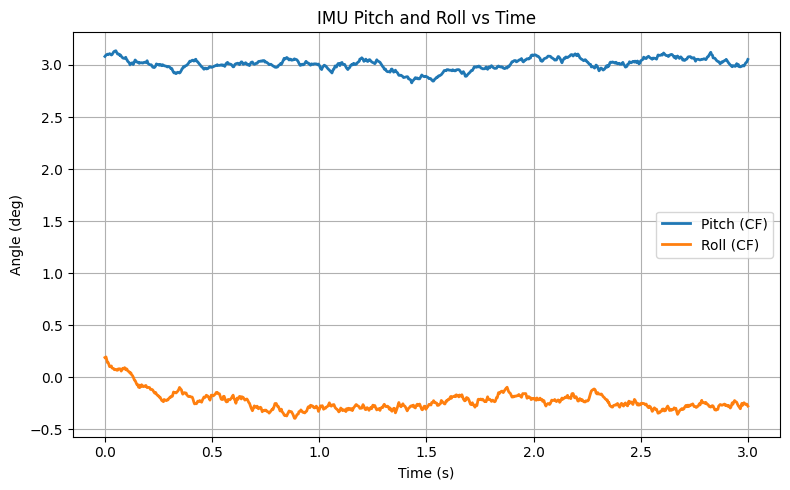

In [43]:
t_imu = np.array(imu_time, dtype=float)
pitch_arr = np.array(pitch, dtype=float)
roll_arr = np.array(roll, dtype=float)

# 转成秒
t_imu = t_imu / 1000.0

plt.figure(figsize=(8,5))

plt.plot(t_imu, pitch_arr, linewidth=2)
plt.plot(t_imu, roll_arr, linewidth=2)

plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("IMU Pitch and Roll vs Time")
plt.legend(["Pitch (CF)", "Roll (CF)"])
plt.grid(True)

plt.tight_layout()
plt.show()